### Drone simulation
This notebook implements a closed-loop multi-fidelity drone simulation using FMUs generated from Modelica component models. <br/>
The simulation integrates four FMUs, drone dynamics, controller, joystick, and mission planner, within a fixed-step time loop, <br/>
where the mission planner generates waypoint commands, the controller computes rotor thrust commands based on sensor feedback, and the drone dynamics model propagates the vehicle state. <br/>
The framework supports multiple fidelity levels of the drone dynamics and allows the injection of various cyber-physical attack scenarios (e.g., EMI disturbance, actuator saturation attack, acoustic IMU attack). <br/>
The simulation outputs time histories of system states, variables, and controller signals for analysis in a unified pandas DataFrame. <br/>
Fidelity: 1 = low-fidelity controller (Euler PID surrogate), 2 = high-fidelity controller (Quaternion PID surrogate) <br/>
Attack_scenario: 0 = no-attack, 1 = parameter change attack, 2 = barometer I2C/SPI bus attack, 3 = gyro acoustic noise injection attack

##### Load packages and required functions
Required python packages: numpy, pandas, OMPython, pyfmi, FMPy <br/>
Used base python packages: logging, time, shutil, os, json, pathlib <br/>
Software: OpenModelica

In [1]:
# load packages
import numpy as np
import dronesim
import os
import glob
import sys
import contextlib
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from utils import quat2eul, eul2quat

@contextlib.contextmanager
def suppress_stdout():
    with open(os.devnull, 'w') as devnull:
        old_stdout = sys.stdout
        sys.stdout = devnull
        try:
            yield
        finally:
            sys.stdout = old_stdout

def simulation_with_controller_webserver(N, tf = 20, dt = 0.1, fidelity = 1, attack_scenario = 0, parameter_file = "rover_parameters.json", fmu_gen = False):
    sim = dronesim.MFQuadrotorCoSIM(fidelity = fidelity, attack_scenario = attack_scenario, parameter_file = parameter_file, fmu_gen = fmu_gen)
    destination = os.path.join(os.getcwd(), f"results/scenario{attack_scenario}")

    if not os.path.exists(destination):
        os.makedirs(destination)

    for idx in range(N):
        file_path = os.path.join(destination, f"simulation_{idx+1}.csv")
        if os.path.isfile(file_path):
            os.remove(file_path)
        df = sim.simulate(tf = tf, dt = dt)
        df.to_csv(file_path, index=False)
        sim.sim_reset()
        print(f"Simulation {idx+1} completed. Results saved to {file_path}")


##### No-attack nominal case simulation (Scenario 0)
Simulation time: 10 seconds <br/>
Monte-Carlo simulation: No, because the no uncertanties assumed in the sensor measurements <br/>
Parameters: All parameters are fixed <br/>
Number of simulations: 1 <br/>
Fidelity level: Cyber model (Lo-Fi) + Physics model (Lo-Fi)

In [2]:
param_file = Path("drone_specs.json").absolute()
verbose = False

if verbose:
    simulation_with_controller_webserver(N = 1, tf = 10, dt = 0.005, attack_scenario = 0, fidelity = 1, parameter_file=param_file, fmu_gen = False)
else:
    with suppress_stdout():
        simulation_with_controller_webserver(N = 1, tf = 10, dt = 0.005, attack_scenario = 0, fidelity = 1, parameter_file=param_file, fmu_gen = False)

Could not find cannot import name 'dopri5' from 'assimulo.lib' (/opt/conda/envs/cp-glimpse-py312/lib/python3.12/site-packages/assimulo/lib/__init__.py)
Could not find cannot import name 'rodas' from 'assimulo.lib' (/opt/conda/envs/cp-glimpse-py312/lib/python3.12/site-packages/assimulo/lib/__init__.py)
Could not find cannot import name 'odassl' from 'assimulo.lib' (/opt/conda/envs/cp-glimpse-py312/lib/python3.12/site-packages/assimulo/lib/__init__.py)
Could not find ODEPACK functions.
Could not find RADAR5
Could not find GLIMDA.


Plotting for Scenario 0

number of result files: 1, plotting ... 


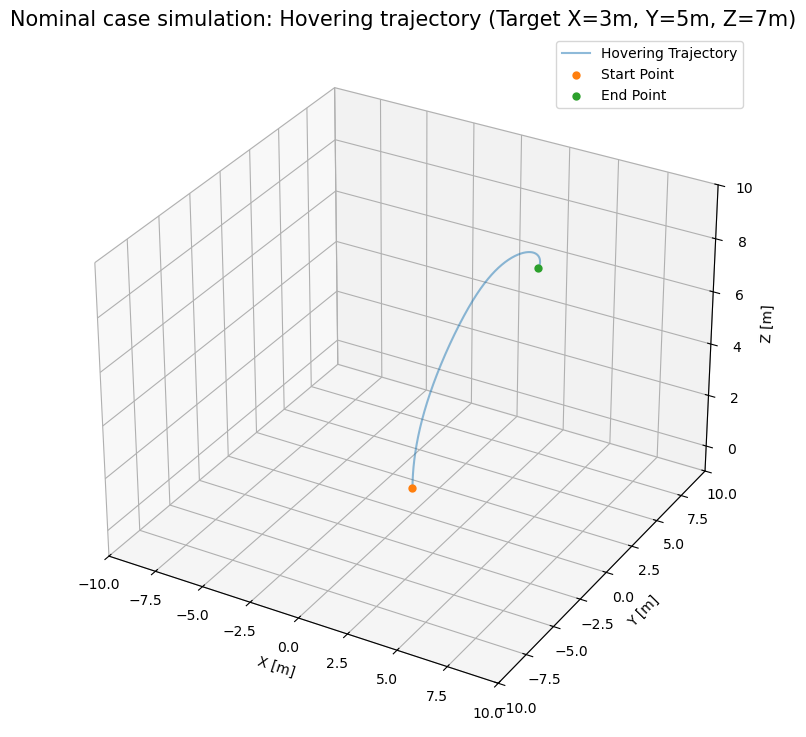

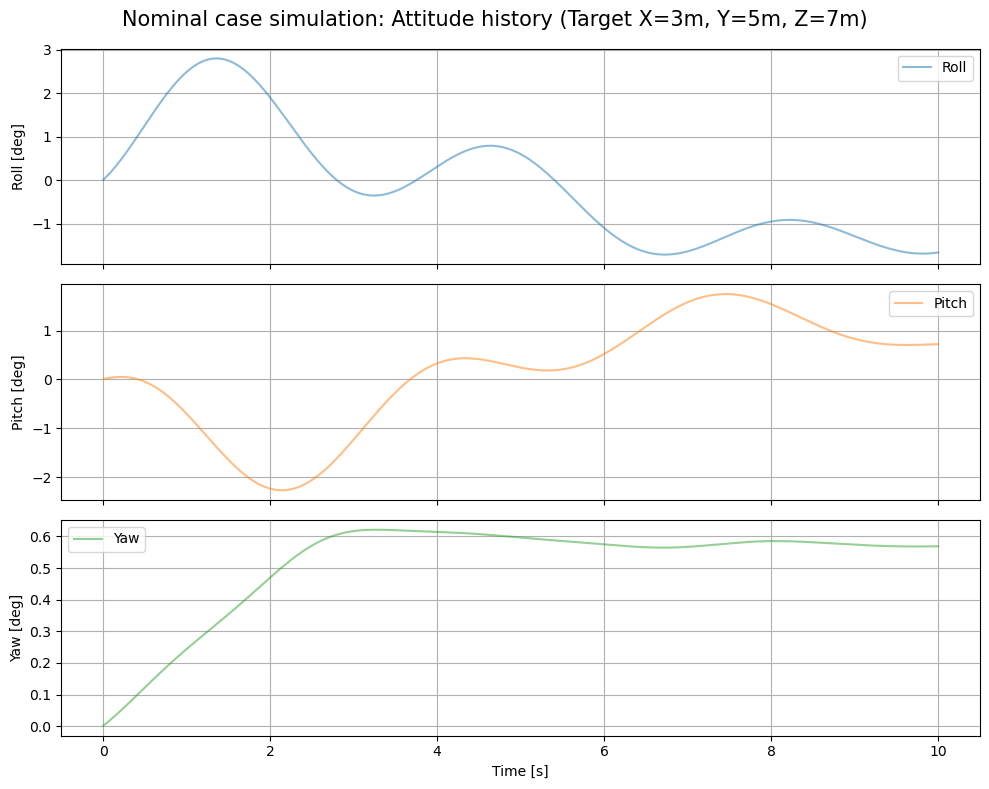

In [3]:
attack_scenario = 0
log_files = glob.glob(os.path.join(os.getcwd(), f"results/scenario{attack_scenario}/*.csv"))
print(f"number of result files: {len(log_files)}, plotting ... ")

if len(log_files) == 1:
    df = pd.read_csv(log_files[0])

    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot(df['quad_low.position_w_p_w[1]'], df['quad_low.position_w_p_w[2]'], -df['quad_low.position_w_p_w[3]'], color='#1f77b4', linestyle='-', linewidth=1.5, alpha=0.5, label='Hovering Trajectory')
    ax.scatter(df['quad_low.position_w_p_w[1]'].iloc[0], df['quad_low.position_w_p_w[2]'].iloc[0], -df['quad_low.position_w_p_w[3]'].iloc[0], color='#ff7f0e', marker='o', linewidth=1.5, label='Start Point')
    ax.scatter(df['quad_low.position_w_p_w[1]'].iloc[-1], df['quad_low.position_w_p_w[2]'].iloc[-1], -df['quad_low.position_w_p_w[3]'].iloc[-1], color='#2ca02c', marker='o', linewidth=1.5, label='End Point')
    ax.set_xlim(-10.0, 10.0)
    ax.set_ylim(-10.0, 10.0)
    ax.set_zlim(-1.0, 10.0) 
    ax.set_xlabel('X [m]')
    ax.set_ylabel('Y [m]')
    ax.set_zlabel('Z [m]')
    ax.set_title('Nominal case simulation: Hovering trajectory (Target X=3m, Y=5m, Z=7m)', fontsize=15)
    ax.legend()

    quad_low_euler_plot = np.zeros((len(df['quad_low.position_w_p_w[1]']), 3))
    for idx in range(len(df['quad_low.position_w_p_w[1]'])):
        quad_low_euler_plot[idx, :] = quat2eul(np.array((df['quad_low.quaternion_wb[1]'].iloc[idx], df['quad_low.quaternion_wb[2]'].iloc[idx], 
                                               df['quad_low.quaternion_wb[3]'].iloc[idx], df['quad_low.quaternion_wb[4]'].iloc[idx])))
    quad_low_euler_df = pd.DataFrame(quad_low_euler_plot, columns=['roll', 'pitch', 'yaw'])

    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    axes[0].plot(df['time'], quad_low_euler_df['roll']/np.pi*180, label='Roll',alpha=0.5,color='#1f77b4')
    axes[0].grid()
    axes[0].legend()
    axes[0].set_ylabel('Roll [deg]')
    axes[1].plot(df['time'], quad_low_euler_df['pitch']/np.pi*180, label='Pitch',alpha=0.5,color='#ff7f0e')
    axes[1].grid()
    axes[1].legend()
    axes[1].set_ylabel('Pitch [deg]')
    axes[2].plot(df['time'], quad_low_euler_df['yaw']/np.pi*180, label='Yaw',alpha=0.5,color='#2ca02c')
    axes[2].grid()
    axes[2].legend()
    axes[2].set_ylabel('Yaw [deg]')
    axes[2].set_xlabel('Time [s]')
    fig.suptitle('Nominal case simulation: Attitude history (Target X=3m, Y=5m, Z=7m)', fontsize=15)
    plt.tight_layout()


##### Gyroscope ultrasound injection attack simulation (Scenario 3)
Simulation time: 10 seconds <br/>
Monte-Carlo simulation: No, acoustic attack parameters (incl. speaker power) are assumed to be fixed for the given scenario <br/>
Parameters: All parameters are fixed <br/>
Number of simulations: 1 <br/>
Fidelity level: Cyber model (Lo-Fi) + Physics model (Lo-Fi)

In [5]:
param_file = Path("drone_specs.json").absolute()
verbose = True

if verbose:
    simulation_with_controller_webserver(N = 1, tf = 10, dt = 0.005, attack_scenario = 3, fidelity = 1, parameter_file=param_file, fmu_gen = False)
else:
    with suppress_stdout():
        simulation_with_controller_webserver(N = 1, tf = 10, dt = 0.005, attack_scenario = 3, fidelity = 1, parameter_file=param_file, fmu_gen = False)

Final Run Statistics: --- 

 Number of steps                                 : 11
 Number of function evaluations                  : 14
 Number of Jacobian evaluations                  : 1
 Number of function eval. due to Jacobian eval.  : 1
 Number of error test failures                   : 0
 Number of nonlinear iterations                  : 11
 Number of nonlinear convergence failures        : 0

Solver options:

 Solver                   : CVode
 Linear multistep method  : BDF
 Nonlinear solver         : Newton
 Linear solver type       : DENSE
 Maximal order            : 5
 Tolerances (absolute)    : 1e-06
 Tolerances (relative)    : 1e-06

Simulation interval    : 0.0 - 0.005 seconds.
Elapsed simulation time: 0.0005672269981005229 seconds.
Final Run Statistics: --- 

 Number of steps                                 : 11
 Number of function evaluations                  : 14
 Number of Jacobian evaluations                  : 1
 Number of function eval. due to Jacobian eval.  : 1
 N

Plotting for Scenario 3

number of result files: 1, plotting ... 


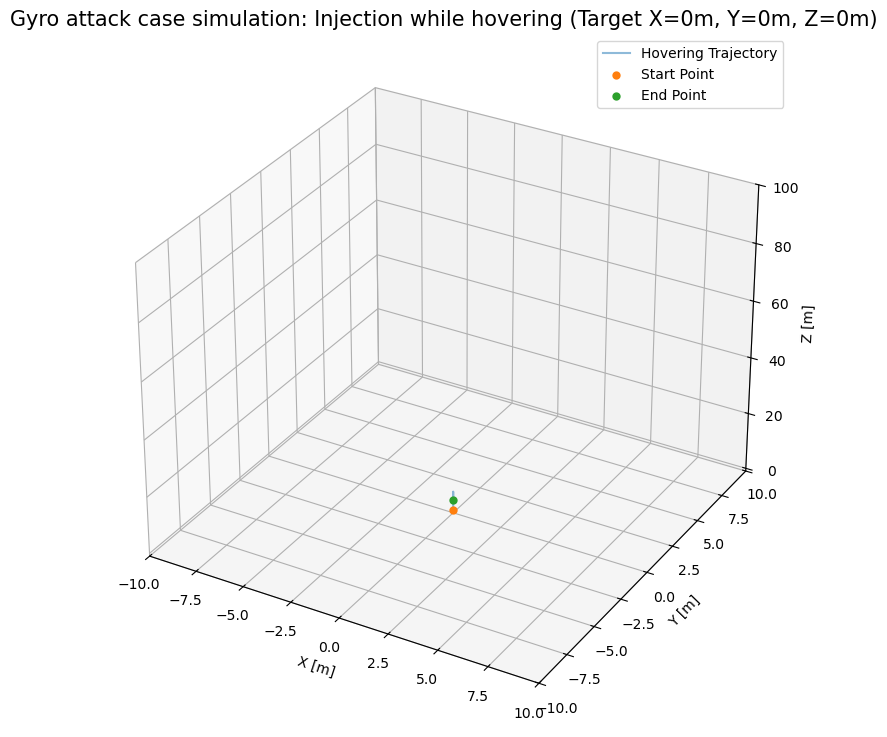

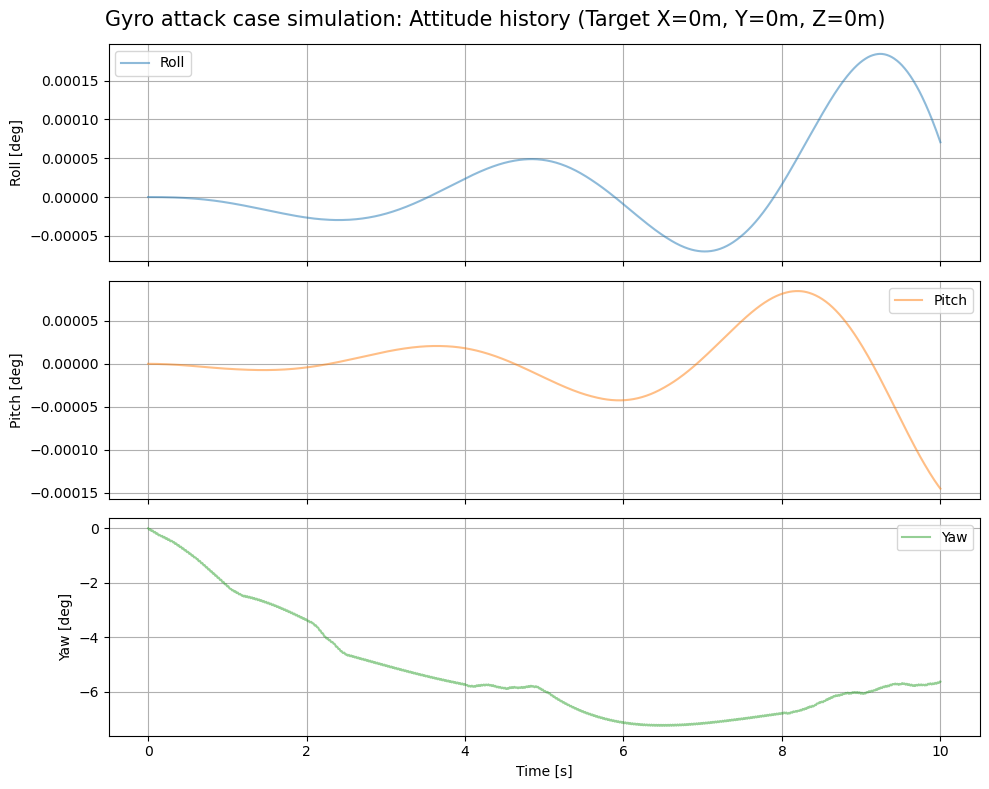

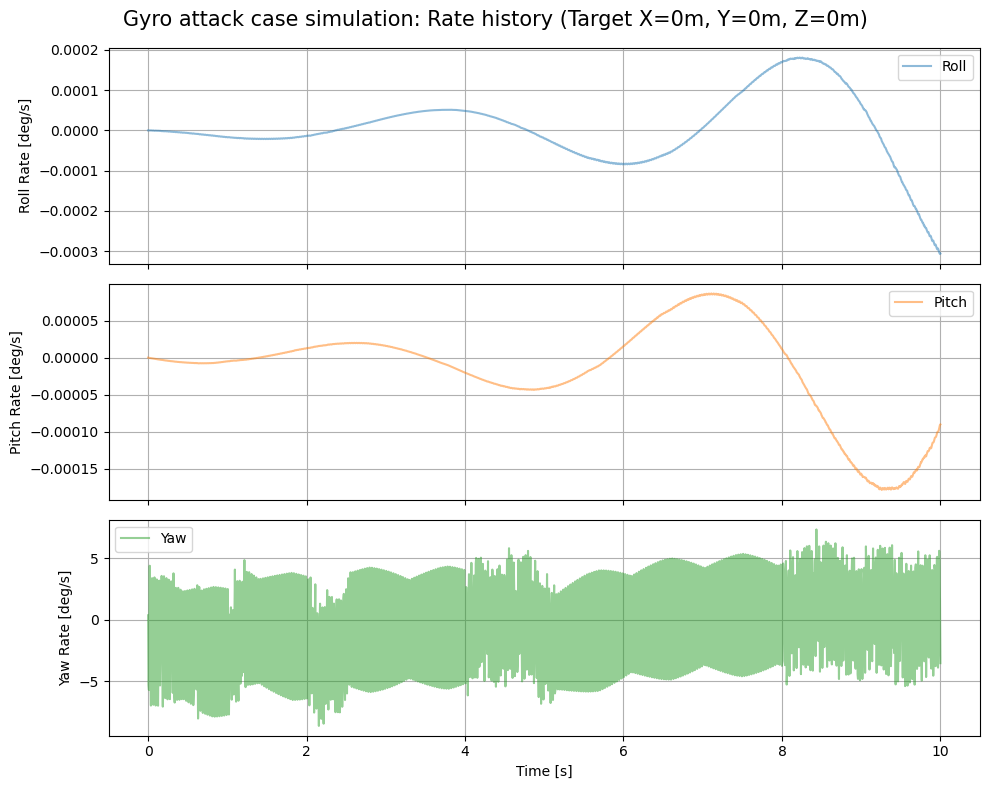

In [6]:
attack_scenario = 3
log_files = glob.glob(os.path.join(os.getcwd(), f"results/scenario{attack_scenario}/*.csv"))
print(f"number of result files: {len(log_files)}, plotting ... ")

if len(log_files) == 1:
    df = pd.read_csv(log_files[0])

    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot(df['quad_low.position_w_p_w[1]'], df['quad_low.position_w_p_w[2]'], -df['quad_low.position_w_p_w[3]'], color='#1f77b4', linestyle='-', linewidth=1.5, alpha=0.5, label='Hovering Trajectory')
    ax.scatter(df['quad_low.position_w_p_w[1]'].iloc[0], df['quad_low.position_w_p_w[2]'].iloc[0], -df['quad_low.position_w_p_w[3]'].iloc[0], color='#ff7f0e', marker='o', linewidth=1.5, label='Start Point')
    ax.scatter(df['quad_low.position_w_p_w[1]'].iloc[-1], df['quad_low.position_w_p_w[2]'].iloc[-1], -df['quad_low.position_w_p_w[3]'].iloc[-1], color='#2ca02c', marker='o', linewidth=1.5, label='End Point')
    ax.set_xlim(-10.0, 10.0)
    ax.set_ylim(-10.0, 10.0)
    ax.set_zlim(-1.0, 100.0) 
    ax.set_xlabel('X [m]')
    ax.set_ylabel('Y [m]')
    ax.set_zlabel('Z [m]')
    ax.set_title('Gyro attack case simulation: Injection while hovering (Target X=0m, Y=0m, Z=0m)', fontsize=15)
    ax.legend()

    quad_low_euler_plot = np.zeros((len(df['quad_low.position_w_p_w[1]']), 3))
    for idx in range(len(df['quad_low.position_w_p_w[1]'])):
        quad_low_euler_plot[idx, :] = quat2eul(np.array((df['quad_low.quaternion_wb[1]'].iloc[idx], df['quad_low.quaternion_wb[2]'].iloc[idx], 
                                               df['quad_low.quaternion_wb[3]'].iloc[idx], df['quad_low.quaternion_wb[4]'].iloc[idx])))
    quad_low_euler_df = pd.DataFrame(quad_low_euler_plot, columns=['roll', 'pitch', 'yaw'])

    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    axes[0].plot(df['time'], quad_low_euler_df['roll']/np.pi*180, label='Roll',alpha=0.5,color='#1f77b4')
    axes[0].grid()
    axes[0].legend()
    axes[0].set_ylabel('Roll [deg]')
    axes[1].plot(df['time'], quad_low_euler_df['pitch']/np.pi*180, label='Pitch',alpha=0.5,color='#ff7f0e')
    axes[1].grid()
    axes[1].legend()
    axes[1].set_ylabel('Pitch [deg]')
    axes[2].plot(df['time'], quad_low_euler_df['yaw']/np.pi*180, label='Yaw',alpha=0.5,color='#2ca02c')
    axes[2].grid()
    axes[2].legend()
    axes[2].set_ylabel('Yaw [deg]')
    axes[2].set_xlabel('Time [s]')
    fig.suptitle('Gyro attack case simulation: Attitude history (Target X=0m, Y=0m, Z=0m)', fontsize=15)
    plt.tight_layout()

    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    axes[0].plot(df['time'], df['quad_low.rate_wb_b[1]']/np.pi*180, label='Roll',alpha=0.5,color='#1f77b4')
    axes[0].grid()
    axes[0].legend()
    axes[0].set_ylabel('Roll Rate [deg/s]')
    axes[1].plot(df['time'], df['quad_low.rate_wb_b[2]']/np.pi*180, label='Pitch',alpha=0.5,color='#ff7f0e')
    axes[1].grid()
    axes[1].legend()
    axes[1].set_ylabel('Pitch Rate [deg/s]')
    axes[2].plot(df['time'], df['quad_low.rate_wb_b[3]']/np.pi*180, label='Yaw',alpha=0.5,color='#2ca02c')
    axes[2].grid()
    axes[2].legend()
    axes[2].set_ylabel('Yaw Rate [deg/s]')
    axes[2].set_xlabel('Time [s]')
    fig.suptitle('Gyro attack case simulation: Rate history (Target X=0m, Y=0m, Z=0m)', fontsize=15)
    plt.tight_layout()
